# Anthropic compute Monte Carlo

Anthropic discloses nothing directly, so we start from one outside anchor: the
leaked OpenAI internal memo, which put Anthropic at about **1.4 GW of compute
online at the end of 2025** (roughly 75% of OpenAI's own 1.9 GW). We treat that
as the *mainline* power figure and bound its uncertainty with the memo's own
logic: OpenAI was confident its **1.9 GW** exceeded Anthropic's, which caps the
high end near 1.8 GW (see §4).

The hard part is turning gigawatts into **H100-equivalents (H100e)**, which
depends on the chip mix. Anthropic's fleet is Trainium2-heavy, with the rest
split between Nvidia (Hopper + Blackwell) and Google TPU. The finding that
simplifies everything: at a fixed power budget the **Nvidia mix and the TPU mix
buy about the same H100e per watt, while Trainium2 buys noticeably less**. So the
fleet collapses to two buckets — high-efficiency non-Trainium (Nvidia or TPU) and
lower-efficiency Trainium2 — and the single lever that moves H100e is the
**Trainium2 share of total power**, which we sweep.

Unlike the OpenAI power model, there is no deployment-lag machinery here: the
memo's 1.4 GW is described as already *online*, and the mix is specified
directly rather than inferred from a vendor's shipment history.

In [1]:
import contextlib
import io
import runpy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squigglepy as sq

N_SAMPLES = 5000
sq.set_seed(42)  # squigglepy has its own RNG; np.random.seed does not affect it

CHIPS = ['H100', 'GB200', 'Trainium2']
CHIP_COLORS = {'H100': '#76b900', 'GB200': '#1a73e8', 'Trainium2': '#e8710a'}


def fmt(value):
    """Format an H100e or chip count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]

## 1. Borrow the Nvidia specs and the H100:GB200 ratio from the OpenAI model

Two things come straight from `openai_compute_monte_carlo.py` so the two
notebooks stay consistent:

- **Per-chip specs** for the Nvidia parts — IT watts per GPU and H100e per GPU.
- **OpenAI's end-2025 H100:GB200 ratio.** OpenAI's fleet also carries trace
  A100 and some GB300; we drop the A100 and fold GB300 into the Blackwell
  bucket, leaving a clean "Hopper vs Blackwell" split that we relabel
  H100 vs GB200 for Anthropic.

We run the OpenAI script once, quietly (its prints and charts suppressed), and
read the numbers out of its namespace.

In [2]:
def load_openai_namespace():
    """Execute the OpenAI notebook script and hand back its variables, without
    letting its own prints or charts render here."""
    oai_path = ('openai_compute_monte_carlo.py'
                if Path('openai_compute_monte_carlo.py').exists()
                else 'ai-lab-compute/openai_compute_monte_carlo.py')
    original_show = plt.show
    plt.show = lambda *args, **kwargs: None  # swallow the OpenAI figures
    try:
        with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
            warnings.simplefilter('ignore')
            namespace = runpy.run_path(oai_path)
    finally:
        plt.show = original_show
        plt.close('all')
    return namespace


openai = load_openai_namespace()
openai_last_date = openai['last_date']
openai_counts = openai['mc'][openai_last_date]['counts']

# OpenAI's per-chip specs (the model calls Blackwell "B200").
oai_watts = openai['watts_per_gpu']
oai_h100e = openai['h100e_per_gpu']

# OpenAI's end-2025 Hopper vs Blackwell chip counts (median across its Monte
# Carlo), A100 dropped. This ratio is what we borrow for Anthropic's Nvidia mix.
hopper_units = float(np.median(openai_counts['H100/H200']))
blackwell_units = float(np.median(openai_counts['B200'] + openai_counts['B300']))
openai_h100_count_fraction = hopper_units / (hopper_units + blackwell_units)

print(f'Borrowed from OpenAI ({openai_last_date.strftime("%Y")} fleet, A100 dropped):')
print(f'   H100  : IT power {oai_watts["H100/H200"]:,.0f} W/GPU, {oai_h100e["H100/H200"]:.3f} H100e/GPU')
print(f'   GB200 : IT power {oai_watts["B200"]:,.0f} W/GPU, {oai_h100e["B200"]:.3f} H100e/GPU')
print(f'   Hopper : Blackwell count ratio = {hopper_units / blackwell_units:.2f} : 1 '
      f'(H100 = {openai_h100_count_fraction:.0%} of Nvidia chips)')

Borrowed from OpenAI (2025 fleet, A100 dropped):
   H100  : IT power 1,389 W/GPU, 1.000 H100e/GPU
   GB200 : IT power 2,083 W/GPU, 2.527 H100e/GPU
   Hopper : Blackwell count ratio = 1.22 : 1 (H100 = 55% of Nvidia chips)


## 2. Chip specs, including Trainium2

The Nvidia specs are the borrowed ones. Trainium2 needs its own two numbers:

- **H100e per chip.** Trainium2's dense 8-bit throughput is 1299 TFLOP/s; an
  H100's is 1979, so one Trainium2 is about two-thirds of an H100e — the same
  ratio Epoch's chip database reports.
- **IT power per chip.** We pin this to a supplied equivalency: a Trainium2
  fleet worth **300k H100e draws 478 MW of IT power**. Dividing through by the
  per-chip H100e gives the server-level watts per chip — about **1050 W**, which
  makes Trainium2 slightly *less* power-efficient than an H100 (a watt of
  Trainium2 buys ~630 H100e, against an H100's ~720). That sits well with the
  summary's note that Anthropic's fleet is less power-efficient per gigawatt
  than OpenAI's.

In [3]:
TRAINIUM2_H100E = 1299 / 1979      # dense 8-bit throughput relative to an H100

# IT power per chip is pinned to a supplied equivalency: a 300k-H100e Trainium2
# fleet draws 478 MW of IT power. With the per-chip H100e above, that fixes both
# the watts per chip and the H100e bought per megawatt of Trainium power.
TRAINIUM2_REF_H100E = 300e3
TRAINIUM2_REF_IT_MW = 478.0
TRAINIUM2_IT_WATTS = TRAINIUM2_H100E / (TRAINIUM2_REF_H100E / TRAINIUM2_REF_IT_MW) * 1e6

WATTS = {
    'H100': oai_watts['H100/H200'],
    'GB200': oai_watts['B200'],
    'Trainium2': TRAINIUM2_IT_WATTS,
}
H100E_PER_CHIP = {
    'H100': oai_h100e['H100/H200'],
    'GB200': oai_h100e['B200'],
    'Trainium2': TRAINIUM2_H100E,
}

print(f'Trainium2: {TRAINIUM2_H100E:.3f} H100e/chip; IT power per chip implied by the '
      f'300k-H100e = 478-MW equivalency = {TRAINIUM2_IT_WATTS:,.0f} W')

Trainium2: 0.656 H100e/chip; IT power per chip implied by the 300k-H100e = 478-MW equivalency = 1,046 W


## 3. Chip efficiency: Nvidia ≈ TPU, Trainium2 lower

At a fixed power budget, the only thing that matters is how much H100e a watt of
IT power buys. We compare three buckets on that metric:

- **Nvidia mix** — H100 + GB200 in OpenAI's borrowed ratio.
- **TPU mix** — Google's actual v5+ fleet from the AI Chip Sales model
  (`tpu_cumulative_by_chip.csv`), each generation weighted by chip count × IT
  power (the OpenAI methodology). TPUs are scored on **native 8-bit peak**,
  consistent with the rest of our work — this flatters the pre-v7 parts that lack
  native FP8, but keeps H100e defined the same way as for the Nvidia chips. TPU
  IT power is TDP × 1.742 (the overhead implied by Nvidia's GB200 NVL72).
- **Trainium2** — pinned to the 300k-H100e = 478-MW equivalency.

The Nvidia and TPU mixes come out within a few percent of each other; Trainium2
is about 0.6× both.

In [4]:
IT_OVERHEAD = 1.742    # IT power per chip / TDP, for TPUs (no public server specs)
H100_FLOPS = 1.979e15  # H100 dense 8-bit FLOP/s, the H100e denominator

# Per-chip H100e per MW for the three modelled chips (from the section-2 specs).
h100e_per_mw = {chip: H100E_PER_CHIP[chip] / WATTS[chip] * 1e6 for chip in CHIPS}

# Nvidia mix: H100 + GB200 in OpenAI's count ratio. A chip type's share of the
# power is its share of the chips, weighted by how many watts each chip draws.
h100_units_per_gb200 = openai_h100_count_fraction / (1 - openai_h100_count_fraction)
h100_power_share = (h100_units_per_gb200 * WATTS['H100']) / (
    h100_units_per_gb200 * WATTS['H100'] + WATTS['GB200'])
nvidia_mix_per_mw = h100_power_share * h100e_per_mw['H100'] + (1 - h100_power_share) * h100e_per_mw['GB200']

# TPU mix: Google's real v5+ fleet, scored on native 8-bit peak.
tpu_tdp_w = {'TPU v5e': 225, 'TPU v5p': 540, 'TPU v6e': 380, 'TPU v7': 960}
tpu_native_8bit_flops = {'TPU v5e': 3.93e14, 'TPU v5p': 9.18e14, 'TPU v6e': 1.836e15, 'TPU v7': 4.614e15}
tpu_it_watts = {chip: tpu_tdp_w[chip] * IT_OVERHEAD for chip in tpu_tdp_w}
tpu_h100e_per_chip = {chip: tpu_native_8bit_flops[chip] / H100_FLOPS for chip in tpu_tdp_w}

for candidate in ('csv_export/tpu_cumulative_by_chip.csv', '../csv_export/tpu_cumulative_by_chip.csv'):
    if Path(candidate).exists():
        tpu_cumulative = pd.read_csv(candidate)
        break
tpu_cumulative['End date'] = pd.to_datetime(tpu_cumulative['End date'])
tpu_snapshot = tpu_cumulative[tpu_cumulative['End date'] == pd.Timestamp('2025-12-31')]
tpu_units = {chip: float(tpu_snapshot.loc[tpu_snapshot['Chip type'] == chip, 'Number of units (median)'].iloc[0])
             for chip in tpu_tdp_w}
tpu_total_it_mw = sum(tpu_units[c] * tpu_it_watts[c] / 1e6 for c in tpu_tdp_w)
tpu_mix_per_mw = sum(tpu_units[c] * tpu_h100e_per_chip[c] for c in tpu_tdp_w) / tpu_total_it_mw

print('Efficiency by bucket (H100e per MW of IT power):')
print(f'   Nvidia mix : {nvidia_mix_per_mw:,.0f}')
print(f'   TPU mix    : {tpu_mix_per_mw:,.0f}   ({tpu_mix_per_mw / nvidia_mix_per_mw:.2f}x the Nvidia mix)')
print(f'   Trainium2  : {h100e_per_mw["Trainium2"]:,.0f}   '
      f'({h100e_per_mw["Trainium2"] / nvidia_mix_per_mw:.2f}x the Nvidia mix)')

Efficiency by bucket (H100e per MW of IT power):
   Nvidia mix : 991
   TPU mix    : 1,018   (1.03x the Nvidia mix)
   Trainium2  : 628   (0.63x the Nvidia mix)


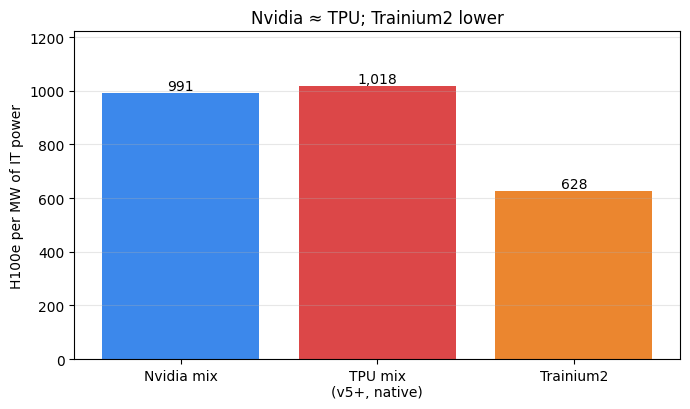

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.2))
buckets = {'Nvidia mix': nvidia_mix_per_mw, 'TPU mix\n(v5+, native)': tpu_mix_per_mw,
           'Trainium2': h100e_per_mw['Trainium2']}
ax.bar(list(buckets), list(buckets.values()), color=['#1a73e8', '#d62728', '#e8710a'], alpha=0.85)
for col, value in enumerate(buckets.values()):
    ax.text(col, value + 12, f'{value:,.0f}', ha='center', fontsize=10)
ax.set_ylabel('H100e per MW of IT power')
ax.set_title('Nvidia ≈ TPU; Trainium2 lower', fontsize=12)
ax.set_ylim(0, max(buckets.values()) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Because the Nvidia and TPU mixes are so close, we treat all non-Trainium compute
as one high-efficiency bucket (their midpoint — the exact Nvidia:TPU split barely
matters) and let Trainium2 keep its 300k = 478 MW value.

In [6]:
nontrainium_per_mw = (nvidia_mix_per_mw + tpu_mix_per_mw) / 2
trainium2_per_mw = h100e_per_mw['Trainium2']
print(f'non-Trainium bucket (Nvidia ≈ TPU): {nontrainium_per_mw:,.0f} H100e/MW')
print(f'Trainium2:                          {trainium2_per_mw:,.0f} H100e/MW')

non-Trainium bucket (Nvidia ≈ TPU): 1,005 H100e/MW
Trainium2:                          628 H100e/MW


## 4. Total power: the OpenAI memo's 1.4 GW

The 1.4 GW figure comes from an OpenAI internal memo that was confident its own
**1.9 GW** exceeded Anthropic's capacity. We use that context to bound the
estimate rather than reaching for a wide prior: the **upper end is ~1.8 GW** —
just under OpenAI's 1.9, since Anthropic is unlikely to be higher if OpenAI
believed it was ahead — and the median stays on the memo's **1.4 GW**. The lower
bound then follows, because a lognormal's median is the geometric mean of its 90%
bounds: left = 1.4² / 1.8 ≈ **1.09 GW**. So the 90% range is about **1.09–1.8 GW**.

One residual risk this band does not fully cover: if the 1.4 GW were *facility*
power rather than IT power, true IT power would be ~30% lower (~1.0 GW), below
this floor.

In [7]:
# Upper bound 1.8 GW (OpenAI's 1.9 was believed to be ahead); left bound set so the
# lognormal median lands on the memo's 1.4 GW (median = geometric mean of bounds).
lab_power_gw = sq.to(1.4 ** 2 / 1.8, 1.8)  # 90% CI ≈ 1.09–1.8 GW, median 1.4
power_samples_mw = (lab_power_gw @ N_SAMPLES) * 1000.0

lo, mid, hi = percentiles(power_samples_mw)
print(f'Anthropic end-2025 IT power (GW): {lo / 1000:.2f} / {mid / 1000:.2f} / {hi / 1000:.2f}  (5th / median / 95th)')

Anthropic end-2025 IT power (GW): 1.09 / 1.41 / 1.79  (5th / median / 95th)


## 5. The Trainium2 share, anchored on the deployment evidence

Instead of sweeping the Trainium2 share, we put a prior on it, anchored on what is
actually known about Anthropic's Trainium2 fleet:

- **Project Rainier (Anthropic's flagship Trainium site) held ~700k Trainium2 at
  end-2025**, against a ~1M target it missed by months. At the central 1.4 GW,
  700k chips × ~1046 W ≈ 730 MW ≈ a **~52% power share**.
- **The Amazon Mississippi campus** may add a few hundred thousand more (less
  certain), pushing Anthropic toward **~1.0M chips ≈ 75% of power**.
- **Amazon had ~1.4M Trainium2 deployed in total at end-2025** ("fully
  subscribed"). That is a hard ceiling: Anthropic is the dominant Trainium2
  customer but not the only one (AWS internal use and other customers take some),
  so Anthropic's slice of that 1.4M is large but well short of all of it.

Putting these together, Anthropic's Trainium2 is **~800k chips central**, which at
1.4 GW is a **~60% power share**. We model the share as roughly **normal with a
90% CI of 0.40–0.80** (median ~0.60). The low end is deliberately loose — it
covers "Rainier only," and the chance that some of Rainier wasn't online or wasn't
Anthropic's at year-end, on the high-power scenario — while the high end is
"Rainier + Mississippi and then some." Share and power are sampled independently
(scale and mix are largely separate questions), and §6 checks that the implied
chip counts stay sane.

In [8]:
def anthropic_h100e(total_power_mw, trainium_share):
    """Total H100e for a power draw and a Trainium2 power share (either may be an
    array of samples; the other broadcasts)."""
    blended_per_mw = trainium_share * trainium2_per_mw + (1 - trainium_share) * nontrainium_per_mw
    return total_power_mw * blended_per_mw


# Prior on the Trainium2 share of IT power (clipped to a sane band).
trainium_share_prior = sq.norm(0.40, 0.80, lclip=0.1, rclip=0.9)
trainium_share = trainium_share_prior @ N_SAMPLES

# Headline Monte Carlo: power and share vary together.
anthropic_h100e_samples = anthropic_h100e(power_samples_mw, trainium_share)

s_lo, s_mid, s_hi = percentiles(trainium_share)
h_lo, h_mid, h_hi = percentiles(anthropic_h100e_samples)
print(f'Trainium2 share prior (5th / median / 95th): {s_lo:.0%} / {s_mid:.0%} / {s_hi:.0%}')
print(f'Anthropic end-2025 H100e (5th / median / 95th): {fmt(h_lo)} / {fmt(h_mid)} / {fmt(h_hi)}')

Trainium2 share prior (5th / median / 95th): 40% / 60% / 80%
Anthropic end-2025 H100e (5th / median / 95th): 837k / 1.09M / 1.42M


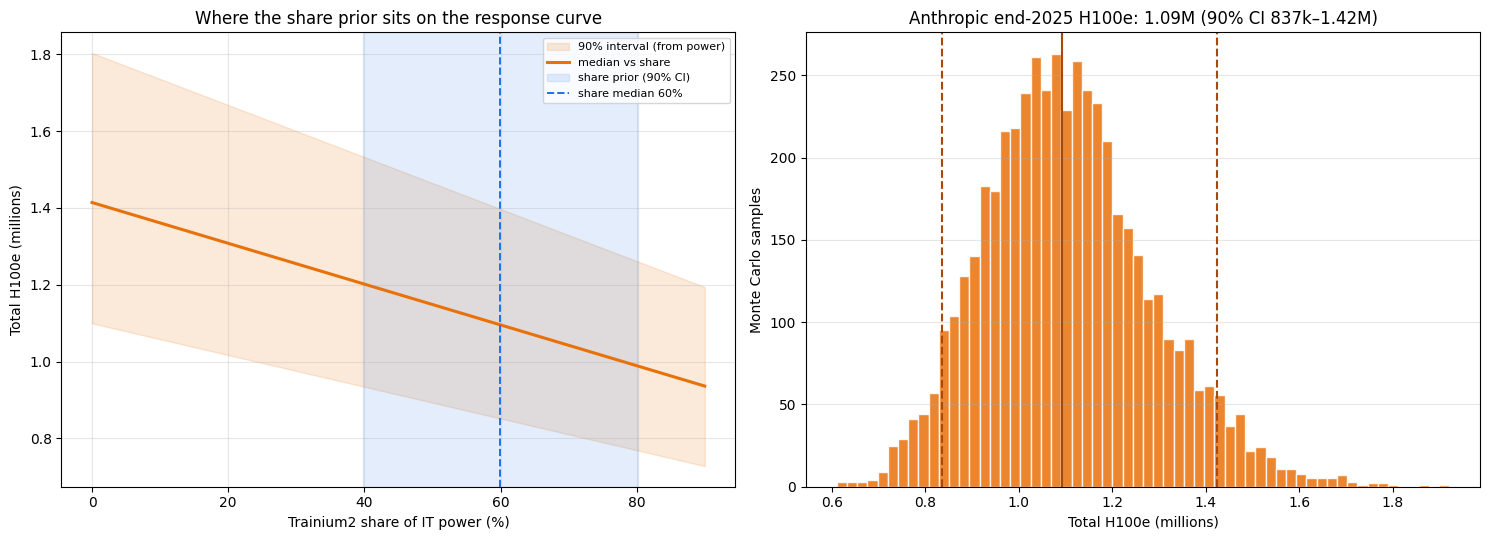

In [9]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: the response curve (median H100e vs share, with the power band), and the
# share prior's 90% CI shaded over it.
share_grid = np.round(np.arange(0.0, 0.901, 0.05), 2)
median_curve = np.array([np.median(anthropic_h100e(power_samples_mw, s)) for s in share_grid]) / 1e6
low_curve = np.array([percentiles(anthropic_h100e(power_samples_mw, s))[0] for s in share_grid]) / 1e6
high_curve = np.array([percentiles(anthropic_h100e(power_samples_mw, s))[2] for s in share_grid]) / 1e6

ax_curve.fill_between(share_grid * 100, low_curve, high_curve, color='#e8710a', alpha=0.15,
                      label='90% interval (from power)')
ax_curve.plot(share_grid * 100, median_curve, color='#e8710a', lw=2.2, label='median vs share')
ax_curve.axvspan(s_lo * 100, s_hi * 100, color='#1a73e8', alpha=0.12, label='share prior (90% CI)')
ax_curve.axvline(s_mid * 100, color='#1a73e8', ls='--', lw=1.4, label=f'share median {s_mid:.0%}')
ax_curve.set_title('Where the share prior sits on the response curve', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of IT power (%)')
ax_curve.set_ylabel('Total H100e (millions)')
ax_curve.legend(loc='upper right', fontsize=8)
ax_curve.grid(True, alpha=0.3)

# Right: the headline H100e distribution (power and share combined).
ax_hist.hist(anthropic_h100e_samples / 1e6, bins=60, color='#e8710a', alpha=0.85, edgecolor='white')
for value, style in zip((h_lo, h_mid, h_hi), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#a8480a', ls=style, lw=1.5)
ax_hist.set_title(f'Anthropic end-2025 H100e: {fmt(h_mid)} (90% CI {fmt(h_lo)}–{fmt(h_hi)})', fontsize=12)
ax_hist.set_xlabel('Total H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Cross-check: implied Trainium2 chip count

The share prior implies a Trainium2 chip count (Trainium2 power ÷ its IT watts).
It should land on the deployment evidence: ~700k at Rainier, plausibly ~1.0M with
Mississippi, and below Amazon's ~1.4M total as a hard ceiling.

Implied Anthropic Trainium2 chips (5th / median / 95th): 498k / 804k / 1.17M
   median is 57% of Amazon's 1.4M total; 0.7% of samples exceed the 1.4M ceiling
   Rainier anchor ~700k; Rainier + Mississippi ~1.0M


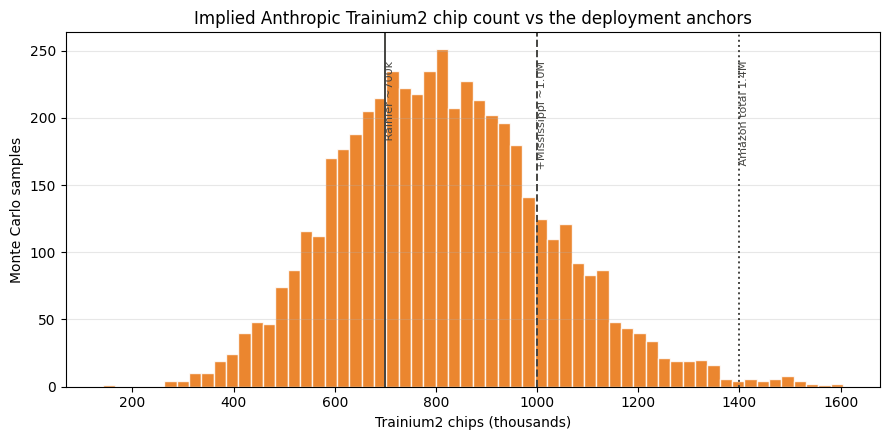

In [10]:
implied_trainium_chips = trainium_share * power_samples_mw * 1e6 / TRAINIUM2_IT_WATTS
c_lo, c_mid, c_hi = percentiles(implied_trainium_chips)
print(f'Implied Anthropic Trainium2 chips (5th / median / 95th): '
      f'{fmt(c_lo)} / {fmt(c_mid)} / {fmt(c_hi)}')
print(f'   median is {c_mid / 1.4e6:.0%} of Amazon\'s 1.4M total; '
      f'{np.mean(implied_trainium_chips > 1.4e6):.1%} of samples exceed the 1.4M ceiling')
print(f'   Rainier anchor ~700k; Rainier + Mississippi ~1.0M')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(implied_trainium_chips / 1e3, bins=60, color='#e8710a', alpha=0.85, edgecolor='white')
for value, label, style in [(700, 'Rainier ~700k', '-'), (1000, '+Mississippi ~1.0M', '--'),
                            (1400, 'Amazon total 1.4M', ':')]:
    ax.axvline(value, color='#444441', ls=style, lw=1.4)
    ax.text(value, ax.get_ylim()[1] * 0.92, f' {label}', rotation=90, va='top', fontsize=8, color='#444441')
ax.set_title('Implied Anthropic Trainium2 chip count vs the deployment anchors', fontsize=12)
ax.set_xlabel('Trainium2 chips (thousands)')
ax.set_ylabel('Monte Carlo samples')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. What drives the uncertainty

Turn each input on alone (the other held at its median) to see how much of the
H100e spread it owns. The non-Trainium composition (Nvidia vs TPU) is left out —
§3 showed it barely moves the total.

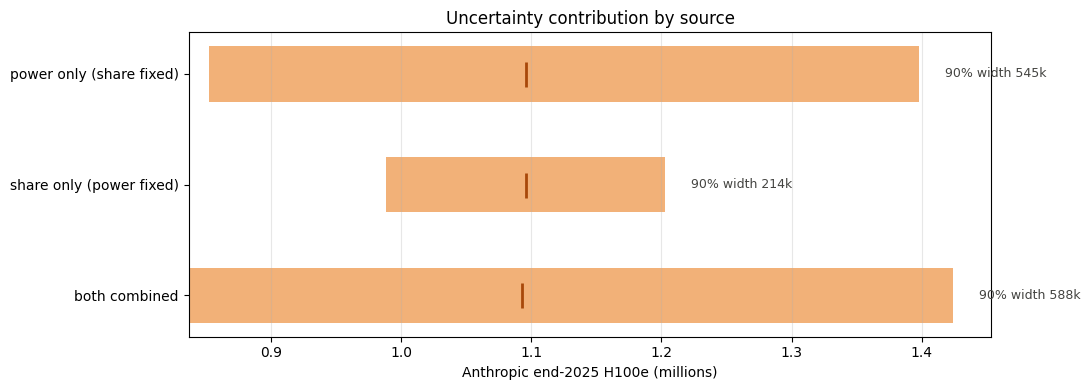

Anthropic end-2025 H100e by source (5th / median / 95th):
   power only (share fixed)  : 852k / 1.10M / 1.40M
   share only (power fixed)  : 988k / 1.10M / 1.20M
   both combined             : 837k / 1.09M / 1.42M


In [11]:
share_median = float(np.median(trainium_share))
power_median_mw = float(np.median(power_samples_mw))

decomposition = {
    'power only (share fixed)': anthropic_h100e(power_samples_mw, share_median),
    'share only (power fixed)': anthropic_h100e(power_median_mw, trainium_share),
    'both combined': anthropic_h100e_samples,
}

fig, ax = plt.subplots(figsize=(11, 4))
for row, (name, samples) in enumerate(decomposition.items()):
    lo, mid, hi = percentiles(samples)
    ax.barh(row, (hi - lo) / 1e6, left=lo / 1e6, color='#e8710a', alpha=0.55, height=0.5)
    ax.plot(mid / 1e6, row, marker='|', color='#a8480a', markersize=18, markeredgewidth=2)
    ax.text((hi + 20000) / 1e6, row, f'90% width {fmt(hi - lo)}', va='center', fontsize=9, color='#444441')
ax.set_yticks(range(len(decomposition)))
ax.set_yticklabels(list(decomposition))
ax.invert_yaxis()
ax.set_xlabel('Anthropic end-2025 H100e (millions)')
ax.set_title('Uncertainty contribution by source', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Anthropic end-2025 H100e by source (5th / median / 95th):')
for name, samples in decomposition.items():
    lo, mid, hi = percentiles(samples)
    print(f'   {name:26s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 8. Takeaways

- **Headline: Anthropic had roughly 1.1M H100e online at end-2025**, with a 90%
  interval of about **0.8M–1.4M** — squarely inside the research summary's "≥1M,
  likely <1.5M" range, and ~60% of OpenAI's ~1.7M.
- **The estimate rests on two inputs: total power and the Trainium2 share.** The
  share prior (median ~60%, 90% CI 40–80%) is anchored on Rainier's ~700k chips
  and Amazon's 1.4M-chip ceiling, with a deliberately loose low end; it implies
  ~800k Anthropic Trainium2 chips at the median, between the two anchors.
- **Power is the larger source of spread** — its ~1.09–1.8 GW band moves H100e
  about three times as much as the share prior does. Tightening the power figure
  is the highest-leverage way to narrow the estimate.
- **Nvidia and TPU are interchangeable here** — within a few percent on H100e per
  watt (native-peak basis), so the non-Trainium split does not affect the total.